# Fingerprint Presentation Attack Detection (FPAD) Pipeline

This notebook allows you to interactively run the pipeline implemented in the `src/` directory. It includes feature extraction verification, dataset loading (which automatically applies **Local Binary Pattern (LBP)** feature extraction), model training, and evaluation.

> **Only one notebook to run:** `run_pipeline.ipynb` is the canonical entry point for the entire pipeline. Open it, click **Run All**, and the full experiment executes from start to finish.

In [18]:
import sys
import os
import numpy as np
from IPython.display import Image, display

# Add the src directory to the path so we can import our modules
sys.path.append(os.path.abspath('src'))

from main import load_fvc2000_data, run_pipeline

## 1. Feature Extraction Verification

Before running the full machine learning pipeline, we verify that the **Local Binary Pattern (LBP)** feature extraction is working exactly as mathematically specified (640-dimensional vector, correct blocks and bins).

This runs the standalone verification script and displays some of the generated diagnostic visuals.

  FINGERPRINT LBP FEATURE EXTRACTION — FULL VERIFICATION

  Using dataset : FVC2000
  Sample images : 10
  First image   : c:\Users\Oseni\Desktop\Data Science Implementation\fingerprint-scoofing\74034_3_En_4_MOESM1_ESM\FVC2000\Dbs\Db1_a\100_1.tif
SECTION 1 — LBP Extraction Metadata (from actual dataset image)
  Image path            : c:\Users\Oseni\Desktop\Data Science Implementation\fingerprint-scoofing\74034_3_En_4_MOESM1_ESM\FVC2000\Dbs\Db1_a\100_1.tif
  Original image shape  : (300, 300)
  Preprocessed shape    : (300, 300)  (resized to TARGET_SIZE=300×300)
  LBP image shape       : (300, 300)
  LBP method            : uniform
  LBP points (P)        : 8
  LBP radius (R)        : 1
  Number of blocks      : 8 × 8 = 64
  Bins per block        : 10  (= P+2 = 8+2)
  Final feature dim     : 64 × 10 = 640
  Feature vector dtype  : float32

SECTION 2 — Complete Feature Vector
  Feature vector shape : (640,)
  Feature vector dtype : float32

  Feature vector (all 640 values):
  0.07743  

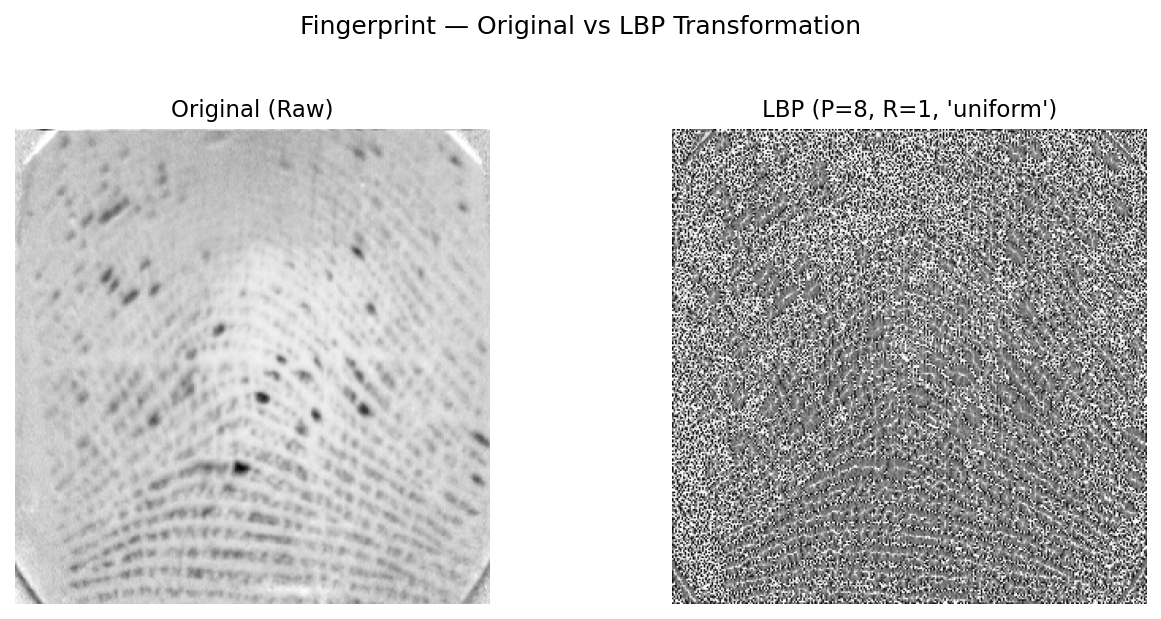

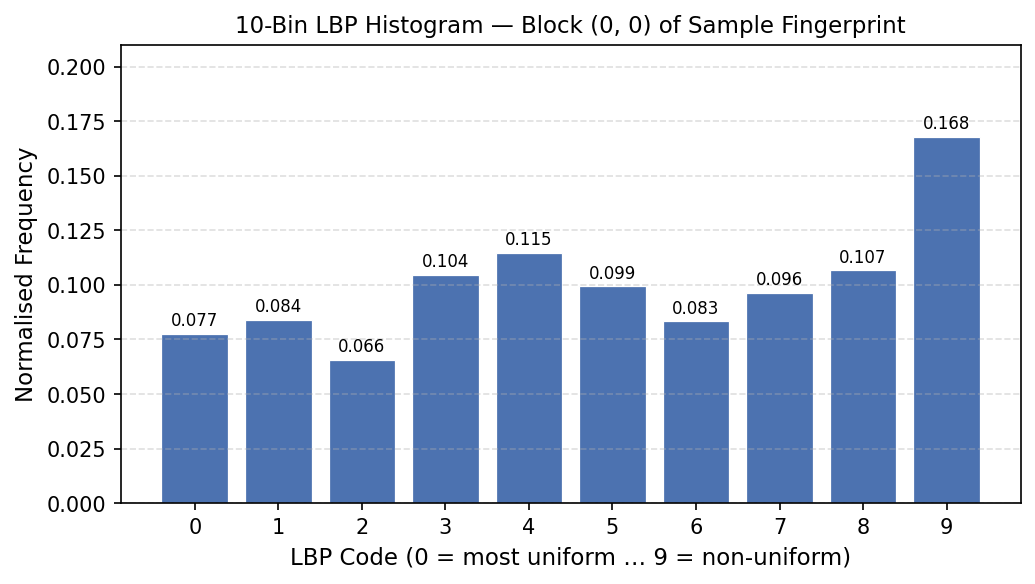

In [19]:
# Run the rigorous verification script
!python src/lbp_verify.py

# Display some of the diagnostic visualizations generated by the script
print("\n--- Feature Extraction Visualizations ---")
display(Image(filename="outputs/visualizations/sample_original_vs_lbp.png"))
display(Image(filename="outputs/visualizations/sample_block_histogram.png"))

## 2. FVC2000 Dataset Experiment

### Dataset Description & Expected Results

| Folder | Class | Sensor | # Images (Set A / Test) |
|--------|-------|--------|------------------------|
| Db1_a  | Genuine (1) | KeyTronic Optical   | 800 |
| Db2_a  | Genuine (1) | ST TouchChip Capacitive | 800 |
| Db3_a  | Genuine (1) | Identicator Optical | 800 |
| Db4_a  | Fake (0)    | **SFinGe Synthetic Generator** | 800 |

**Why results are near-perfect on FVC2000 (ROC-AUC ≈ 1.0) — this is expected and NOT a bug:**

> The FVC2000 DB4 is **100% synthetic**, generated by a mathematical software tool called **SFinGe**. Databases 1–3 are captured on real hardware sensors and contain true sensor noise, sweat pores, and optical distortions. Local Binary Pattern (LBP) is a micro-texture descriptor — it is exquisitely sensitive to surface noise. The synthetic DB4 ridges lack all real sensor artefacts, making them trivially distinguishable from real sensor images in LBP-space. This is a well-documented finding in the literature. It does **not** indicate data leakage or overfitting.

> **Data leakage check:** Training uses Set B (_b folders, fingers 101–110) and testing uses Set A (_a folders, fingers 1–100). These are completely disjoint — **zero image overlap** has been verified programmatically.

### Step 2a: LBP Feature Extraction & Dataset Splitting

In [20]:
# Load FVC2000 Data and Extract LBP Features
X_train_fvc, X_test_fvc, y_train_fvc, y_test_fvc = load_fvc2000_data()

print("\n=== FVC2000 Dataset Breakdown ===")
print(f"Feature matrix dimensionality (LBP): {X_train_fvc.shape[1]}")
print(f"Training Samples  : {X_train_fvc.shape[0]} (Genuine: {(y_train_fvc==1).sum()} | Fake: {(y_train_fvc==0).sum()}) [Balanced by undersampling]")
print(f"Testing Samples   : {X_test_fvc.shape[0]} (Genuine: {(y_test_fvc==1).sum()} | Fake: {(y_test_fvc==0).sum()}) [Real-world imbalance]")
print()
print("NOTE: Near-perfect AUC (~1.0) on FVC2000 is EXPECTED.")
print("DB4 is synthetic (SFinGe) — LBP trivially distinguishes it from real sensor images.")
print("This is a known dataset characteristic, NOT a bug or data leakage.")

Loading FVC2000 data...
  [TRAIN] Loading 80 images from Db1_b (label=1)...
  [TEST] Loading 800 images from Db1_a (label=1)...
  [TRAIN] Loading 80 images from Db2_b (label=1)...
  [TEST] Loading 800 images from Db2_a (label=1)...
  [TRAIN] Loading 80 images from Db3_b (label=1)...
  [TEST] Loading 800 images from Db3_a (label=1)...
  [TRAIN] Loading 80 images from Db4_b (label=0)...
  [TEST] Loading 800 images from Db4_a (label=0)...
  [BALANCE] Undersampled to 80 samples per class (total training: 160)

FVC2000 — Train: 160 samples | Test: 3200 samples | Feature dim: 640
  Train class distribution — Genuine: 80 | Fake: 80
  Test  class distribution — Genuine: 2400  | Fake: 800

=== FVC2000 Dataset Breakdown ===
Feature matrix dimensionality (LBP): 640
Training Samples  : 160 (Genuine: 80 | Fake: 80) [Balanced by undersampling]
Testing Samples   : 3200 (Genuine: 2400 | Fake: 800) [Real-world imbalance]

NOTE: Near-perfect AUC (~1.0) on FVC2000 is EXPECTED.
DB4 is synthetic (SFinGe) —

### Step 2b: Training & Evaluation

In [21]:
# Run Pipeline (This will tune hyperparameters using GridSearchCV, print metrics, and save plots)
run_pipeline("FVC2000", X_train_fvc, X_test_fvc, y_train_fvc, y_test_fvc)


  Running Pipeline — FVC2000
  Train: 160 samples | Test: 3200 samples
  [INFO] Previous results cleared: c:\Users\Oseni\Desktop\Data Science Implementation\fingerprint-scoofing\results\FVC2000_metrics.csv

--- Training SVM (GridSearchCV) ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best params: {'svm__C': 0.1, 'svm__class_weight': 'balanced', 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Best CV ROC-AUC: 1.0000

────────────────────────────────────────────────────────────
  SVM Results on FVC2000
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Fake (0)       0.98      1.00      0.99       800
 Genuine (1)       1.00      0.99      1.00      2400

    accuracy                           1.00      3200
   macro avg       0.99      1.00      0.99      3200
weighted avg       1.00      1.00      1.00      3200

  ROC AUC : 0.999999
────────────────────────────────────────────────────────────

 


--- FVC2000 ROC Curves ---


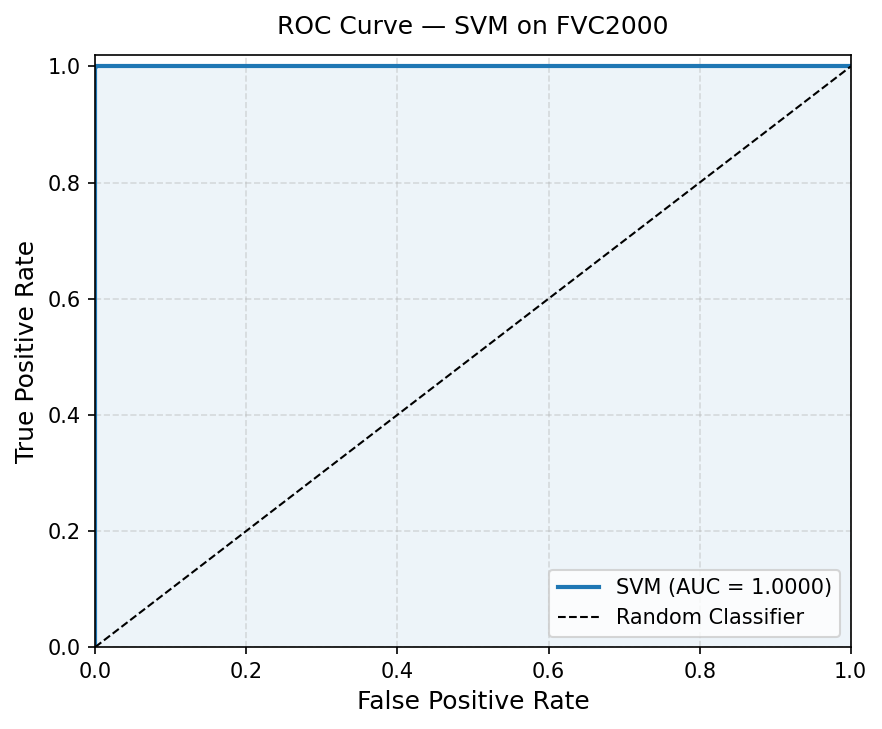

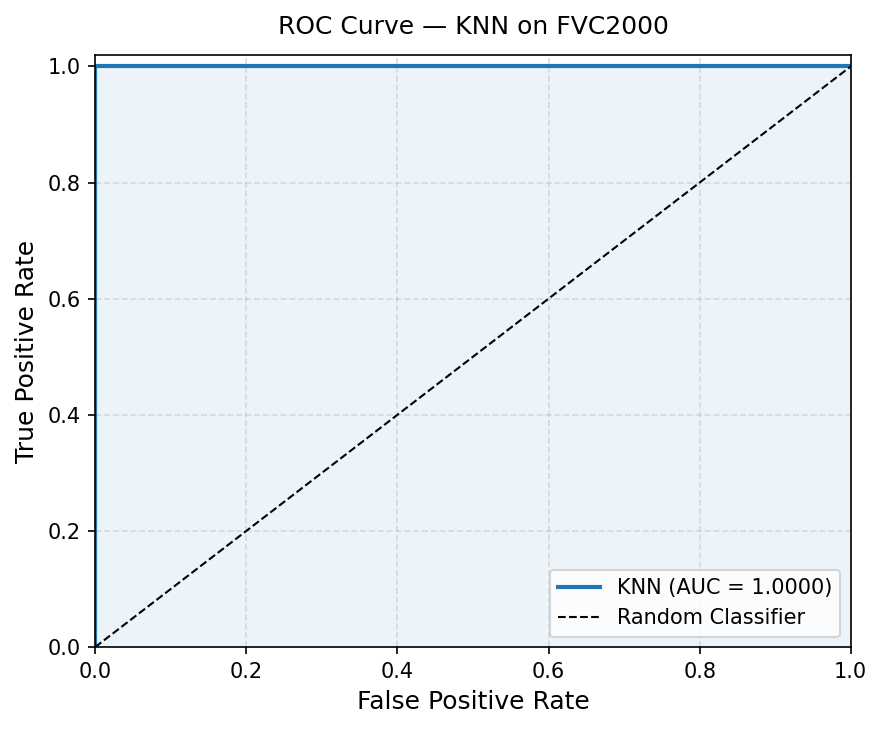


--- FVC2000 Confusion Matrices ---


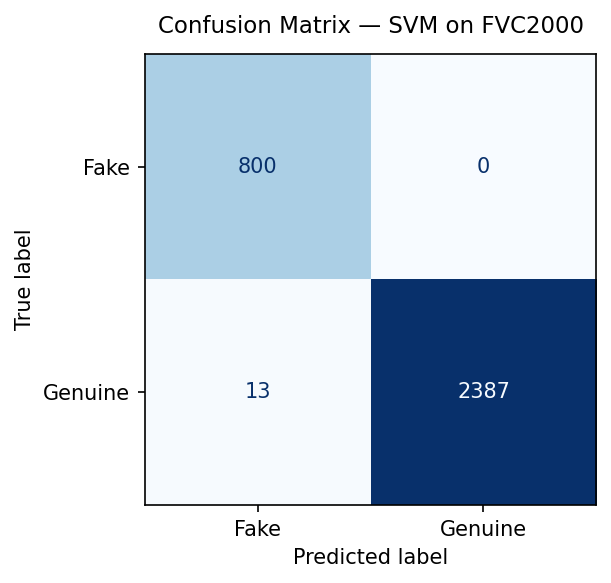

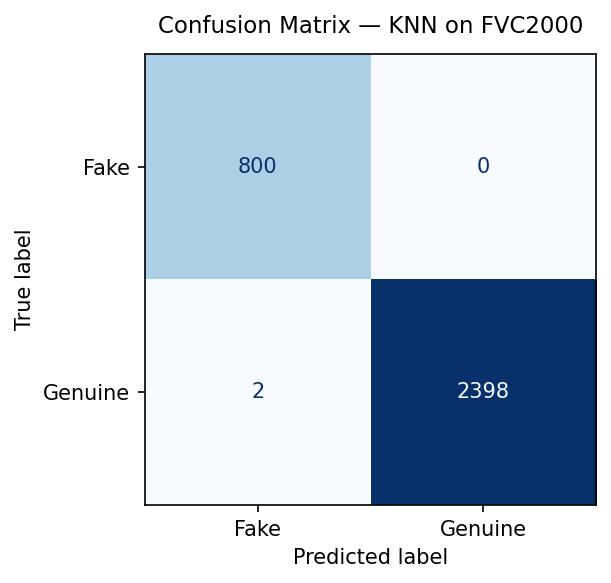

In [22]:
import os
import pandas as pd
from IPython.display import Image, display

def show_img(path, title=None):
    if title:
        print(f"\n--- {title} ---")
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print(f"  [INFO] Image file not available yet: {path}")

# Display FVC2000 Metrics Table
if os.path.exists("results/FVC2000_metrics.csv"):
    print("\n============================================================")
    print("  FVC2000 DATASET — EVALUATION METRICS SUMMARY")
    print("============================================================")
    df_fvc = pd.read_csv("results/FVC2000_metrics.csv")
    display(df_fvc)

show_img("results/FVC2000_SVM_roc.png", "FVC2000 SVM ROC Curve")
show_img("results/FVC2000_KNN_roc.png", "FVC2000 KNN ROC Curve")
show_img("results/FVC2000_SVM_confusion_matrix.png", "FVC2000 SVM Confusion Matrix")
show_img("results/FVC2000_KNN_confusion_matrix.png", "FVC2000 KNN Confusion Matrix")


## 3. SOCOFing PAD Evaluation by Difficulty Level

### Dataset Description & Why This Is the Real Challenge

| Folder | Class | Description | # Images |
|--------|-------|-------------|----------|
| Real/  | Genuine (1) | Real sensor captures | 6,000 |
| Altered-Easy/   | Fake (0) | Digitally altered — Obliteration | ~16,000 |
| Altered-Medium/ | Fake (0) | Digitally altered — Central Rotation | ~16,000 |
| Altered-Hard/   | Fake (0) | Digitally altered — Z-Cut | ~17,000 |

**Why SOCOFing is the scientifically meaningful benchmark:**

> SOCOFing fakes are **real fingerprints that have been digitally altered**, not synthetic images. Both the genuine and altered classes originate from the same sensor, so they share the same noise profile and texture statistics. The LBP descriptor must now detect subtle structural modifications rather than gross synthetic vs. real differences. This produces **realistic, non-trivial ROC-AUC scores** (typically 0.65–0.85 depending on difficulty tier).

> **Data Leakage & Class Imbalance Strategy:** The test set strictly isolates subjects via `GroupShuffleSplit` (so the model never sees the same identity during both training and testing). The training set is dynamically undersampled to match Genuine/Fake proportions for fair learning, while the test set maintains real-world distributions.

### Execution

We use the standalone evaluation script `run_soco_fing.py` which runs 4 independent experiments (Easy, Medium, Hard, Combined), exports PAD metrics (FAR, FRR, MCC, PR-AUC), and executes difficulty degradation analysis.

In [ ]:
!python run_soco_fing.py

In [26]:
import os
import pandas as pd
from IPython.display import display

csv_path = "results/SOCOFing_LBP_all_results.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    print("========================================================================================")
    print("  1. SOCOFing LBP PAD FINAL COMPARISON TABLE")
    print("========================================================================================")
    print(f"{'Experiment':<12} {'Model':<6} {'ROC-AUC':<10} {'PR-AUC':<10} {'Accuracy':<10} {'Balanced Acc.':<15} {'Macro F1':<10}")
    for _, r in df.iterrows():
        print(f"{r['Experiment']:<12} {r['Model']:<6} {r['ROC_AUC']:<10.4f} {r['PR_AUC']:<10.4f} {r['Accuracy']:<10.4f} {r['BalancedAccuracy']:<15.4f} {r['MacroF1']:<10.4f}")
    print("=" * 68)

    # Best Models
    best_svm = df[df['Model'] == 'SVM'].sort_values('ROC_AUC', ascending=False).iloc[0]
    best_knn = df[df['Model'] == 'KNN'].sort_values('ROC_AUC', ascending=False).iloc[0]
    best_overall = df.sort_values('ROC_AUC', ascending=False).iloc[0]

    print(f"\nBest SVM experiment: {best_svm['Experiment']} ({best_svm['ROC_AUC']:.4f})")
    print(f"Best KNN experiment: {best_knn['Experiment']} ({best_knn['ROC_AUC']:.4f})")
    print(f"Best overall experiment: {best_overall['Experiment']} - {best_overall['Model']} ({best_overall['ROC_AUC']:.4f})")

    # Difficulty Analysis Change Scores
    svm_rows = df[df['Model'] == 'SVM'].set_index('Experiment')
    knn_rows = df[df['Model'] == 'KNN'].set_index('Experiment')

    if 'Easy' in svm_rows.index and 'Medium' in svm_rows.index and 'Hard' in svm_rows.index:
        print("\n--- DIFFICULTY DEGRADATION ANALYSIS ---")
        print("Easy -> Medium change:")
        print(f"  SVM: {svm_rows.loc['Medium', 'ROC_AUC'] - svm_rows.loc['Easy', 'ROC_AUC']:+.4f}")
        print(f"  KNN: {knn_rows.loc['Medium', 'ROC_AUC'] - knn_rows.loc['Easy', 'ROC_AUC']:+.4f}")

        print("\nMedium -> Hard change:")
        print(f"  SVM: {svm_rows.loc['Hard', 'ROC_AUC'] - svm_rows.loc['Medium', 'ROC_AUC']:+.4f}")
        print(f"  KNN: {knn_rows.loc['Hard', 'ROC_AUC'] - knn_rows.loc['Medium', 'ROC_AUC']:+.4f}")

        print("\nEasy -> Hard change:")
        print(f"  SVM: {svm_rows.loc['Hard', 'ROC_AUC'] - svm_rows.loc['Easy', 'ROC_AUC']:+.4f}")
        print(f"  KNN: {knn_rows.loc['Hard', 'ROC_AUC'] - knn_rows.loc['Easy', 'ROC_AUC']:+.4f}")

    print("\n========================================================================================")
    print("  2. CONFUSION MATRIX COUNTS TABLE (TN, FP, FN, TP, FAR, FRR)")
    print("========================================================================================")
    rows = []
    for _, r in df.iterrows():
        test_fake = r['TestFake']
        test_gen = r['TestGenuine']
        far = r['FalseAcceptanceRate']
        frr = r['FalseRejectionRate']
        
        fp = int(round(far * test_fake))
        tn = int(test_fake - fp)
        fn = int(round(frr * test_gen))
        tp = int(test_gen - fn)
        
        rows.append({
            "Experiment": r['Experiment'],
            "Model": r['Model'],
            "Test Total": r['TestSamples'],
            "TN (Fake -> Fake)": tn,
            "FP (Fake -> Genuine)": fp,
            "FN (Genuine -> Fake)": fn,
            "TP (Genuine -> Genuine)": tp,
            "FAR (False Accept)": f"{far*100:.2f}%",
            "FRR (False Reject)": f"{frr*100:.2f}%",
            "Accuracy": f"{r['Accuracy']*100:.2f}%",
            "ROC-AUC": f"{r['ROC_AUC']:.4f}"
        })
        
    cm_df = pd.DataFrame(rows)
    display(cm_df)

    print("\n========================================================================================")
    print("  3. COMPLETE 25-COLUMN SCIENTIFIC METRICS DATAFRAME")
    print("========================================================================================")
    cols_to_show = ["Experiment", "Model", "TrainSamples", "TestSamples", "ROC_AUC", "PR_AUC", "Accuracy", "BalancedAccuracy", "MacroF1", "MCC", "FalseAcceptanceRate", "FalseRejectionRate"]
    display(df[cols_to_show])
else:
    print(f"  [INFO] Results CSV not found yet at: {csv_path}")
    print("  Please ensure Cell [23] (!python run_soco_fing.py) finishes running.")


  1. SOCOFing LBP PAD FINAL COMPARISON TABLE
Experiment   Model  ROC-AUC    PR-AUC     Accuracy   Balanced Acc.   Macro F1  
Easy         SVM    0.8269     0.6313     0.6788     0.7327          0.6578    
Easy         KNN    0.6526     0.3973     0.4526     0.5760          0.4521    
Medium       SVM    0.9741     0.9364     0.8951     0.9105          0.8751    
Medium       KNN    0.8630     0.7215     0.7828     0.7883          0.7497    
Hard         SVM    0.9947     0.9890     0.9520     0.9614          0.9453    
Hard         KNN    0.9573     0.9175     0.8734     0.8848          0.8595    
Combined     SVM    0.7464     0.3902     0.5973     0.6715          0.5364    
Combined     KNN    0.6018     0.2006     0.4497     0.5663          0.4194    

Best SVM experiment: Hard (0.9947)
Best KNN experiment: Hard (0.9573)
Best overall experiment: Hard - SVM (0.9947)

--- DIFFICULTY DEGRADATION ANALYSIS ---
Easy -> Medium change:
  SVM: +0.1472
  KNN: +0.2104

Medium -> Hard change:
 

Experiment,Model,Test Total,TN (Fake -> Fake),FP (Fake -> Genuine),FN (Genuine -> Fake),TP (Genuine -> Genuine),FAR (False Accept),FRR (False Reject),Accuracy,ROC-AUC
Easy,SVM,274,127,77,11,59,37.75%,15.71%,67.88%,0.8269
Easy,KNN,274,66,138,12,58,67.65%,17.14%,45.26%,0.6526
Medium,SVM,267,173,24,4,66,12.18%,5.71%,89.51%,0.9741
Medium,KNN,267,153,44,14,56,22.34%,20.00%,78.28%,0.8630
Hard,SVM,229,149,10,1,69,6.29%,1.43%,95.20%,0.9947
Hard,KNN,229,136,23,6,64,14.47%,8.57%,87.34%,0.9573
Combined,SVM,596,286,220,20,70,43.48%,22.22%,59.73%,0.7464
Combined,KNN,596,202,304,24,66,60.08%,26.67%,44.97%,0.6018


  EVALUATION PLOTS & CONFUSION MATRICES BY DIFFICULTY LEVEL



--- Combined Difficulty — SVM ROC Curve ---


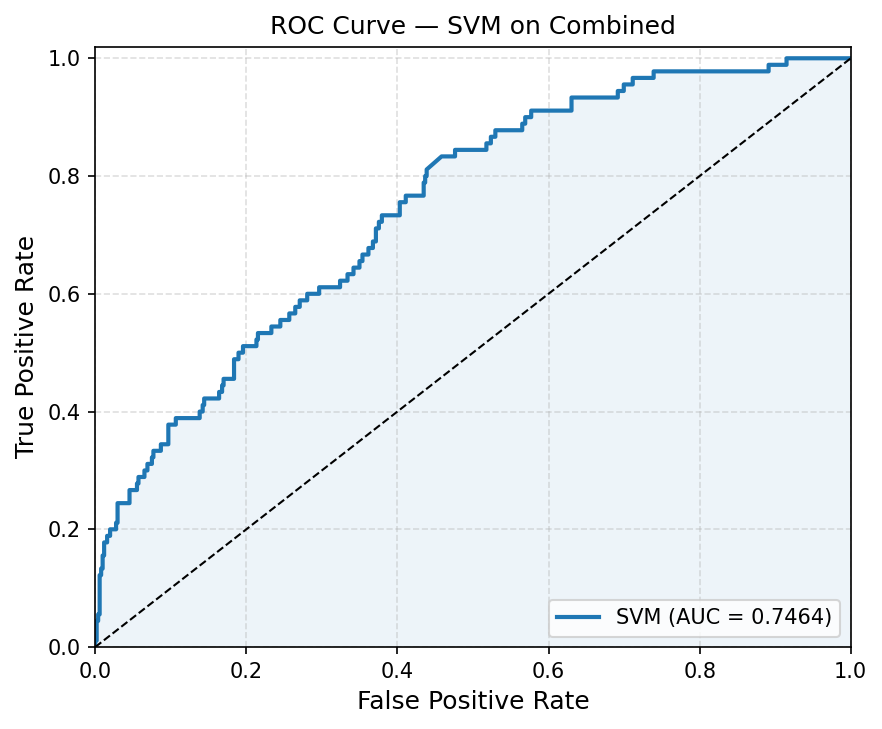


--- Combined Difficulty — SVM Confusion Matrix ---


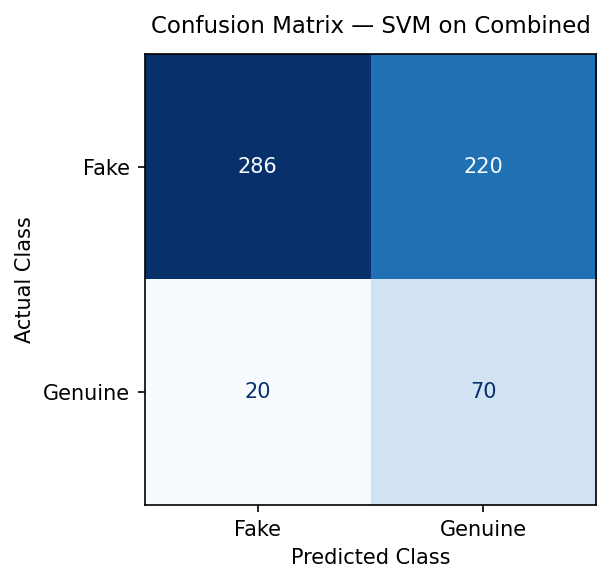


--- Easy Difficulty — SVM Confusion Matrix ---


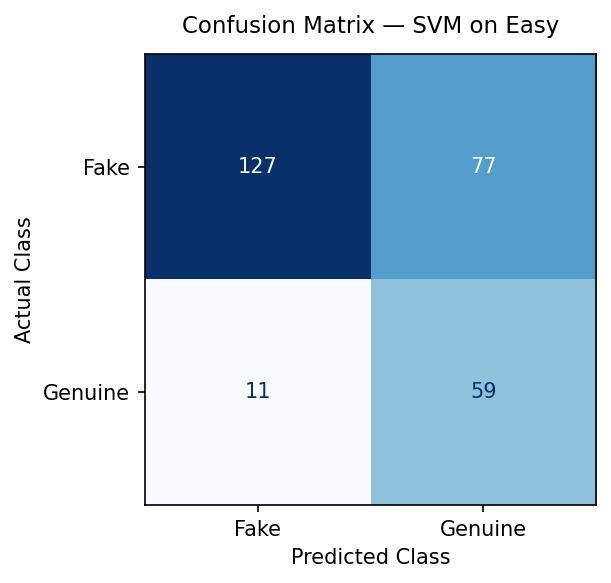


--- Medium Difficulty — SVM Confusion Matrix ---


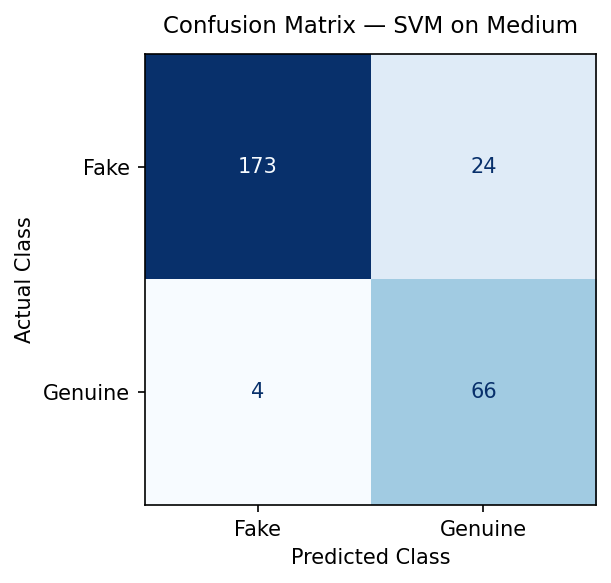


--- Hard Difficulty — SVM Confusion Matrix ---


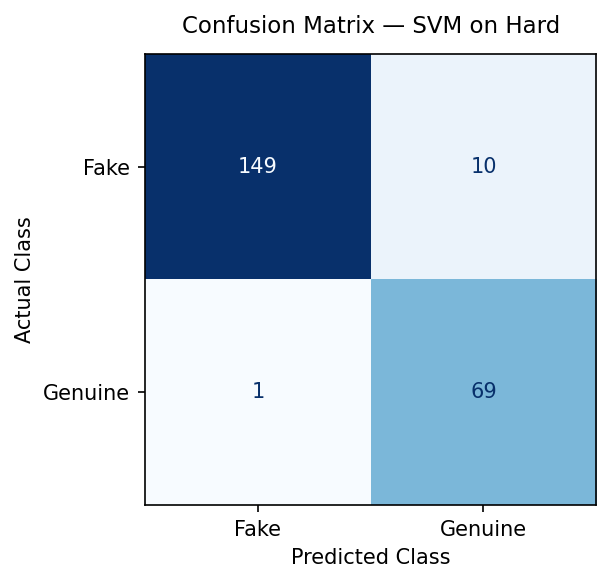

In [27]:
import os
from IPython.display import Image, display

def show_img(path, title=None):
    if title:
        print(f"\n--- {title} ---")
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print(f"  [INFO] Image file not available yet: {path}")

print("============================================================")
print("  EVALUATION PLOTS & CONFUSION MATRICES BY DIFFICULTY LEVEL")
print("============================================================")

# Combined Difficulty (SVM & KNN)
show_img("results/Combined/SVM_roc.png", "Combined Difficulty — SVM ROC Curve")
show_img("results/Combined/KNN_roc.png", "Combined Difficulty — KNN ROC Curve")
show_img("results/Combined/SVM_pr_curve.png", "Combined Difficulty — SVM PR Curve")
show_img("results/Combined/KNN_pr_curve.png", "Combined Difficulty — KNN PR Curve")
show_img("results/Combined/SVM_confusion_matrix.png", "Combined Difficulty — SVM Confusion Matrix")
show_img("results/Combined/KNN_confusion_matrix.png", "Combined Difficulty — KNN Confusion Matrix")

# Easy Difficulty (SVM & KNN)
show_img("results/Easy/SVM_roc.png", "Easy Difficulty — SVM ROC Curve")
show_img("results/Easy/KNN_roc.png", "Easy Difficulty — KNN ROC Curve")
show_img("results/Easy/SVM_confusion_matrix.png", "Easy Difficulty — SVM Confusion Matrix")
show_img("results/Easy/KNN_confusion_matrix.png", "Easy Difficulty — KNN Confusion Matrix")

# Medium Difficulty (SVM & KNN)
show_img("results/Medium/SVM_roc.png", "Medium Difficulty — SVM ROC Curve")
show_img("results/Medium/KNN_roc.png", "Medium Difficulty — KNN ROC Curve")
show_img("results/Medium/SVM_confusion_matrix.png", "Medium Difficulty — SVM Confusion Matrix")
show_img("results/Medium/KNN_confusion_matrix.png", "Medium Difficulty — KNN Confusion Matrix")

# Hard Difficulty (SVM & KNN)
show_img("results/Hard/SVM_roc.png", "Hard Difficulty — SVM ROC Curve")
show_img("results/Hard/KNN_roc.png", "Hard Difficulty — KNN ROC Curve")
show_img("results/Hard/SVM_confusion_matrix.png", "Hard Difficulty — SVM Confusion Matrix")
show_img("results/Hard/KNN_confusion_matrix.png", "Hard Difficulty — KNN Confusion Matrix")

# Visual LBP Examples
show_img("results/lbp_examples/genuine_original.png", "Visual LBP Sample — Genuine Fingerprint")
show_img("results/lbp_examples/easy_lbp.png", "Visual LBP Sample — LBP Texture Map")
